# 5-Armed Bandit Task
**Human operant exploration-exploitation experiment**

Participants press one of 5 buttons to earn points. Each button pays out differently, and the values drift over time — so exploration is always necessary.

After the task, we fit a Q-learning model to extract each participant's **learning rate (α)** and **exploration temperature (τ)**.

---
## Cell 1 — Install / import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

---
## Cell 2 — Task parameters (edit here)

In [2]:
# ── Task configuration ────────────────────────────────────────────────
PARTICIPANT_ID = 'P01'       # Change for each participant
N_ARMS         = 5           # Number of buttons
N_TRIALS       = 200         # Total trials
REWARD_SD      = 4           # Noise on each reward draw (Gaussian)
DRIFT_SD       = 0.5         # How fast true means drift (random walk step)
INIT_MEAN_RANGE = (20, 80)   # Starting mean range for each arm (points)
BUTTON_LABELS  = ['A', 'B', 'C', 'D', 'E']
BUTTON_COLORS  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
# ─────────────────────────────────────────────────────────────────────

np.random.seed(None)  # Fresh random seed each run

# Pre-generate the reward environment (true means drift over trials)
true_means = np.zeros((N_TRIALS, N_ARMS))
true_means[0] = np.random.uniform(*INIT_MEAN_RANGE, size=N_ARMS)
for t in range(1, N_TRIALS):
    true_means[t] = true_means[t-1] + np.random.normal(0, DRIFT_SD, N_ARMS)
    true_means[t] = np.clip(true_means[t], 0, 100)  # keep in 0-100 range

print(f'Task ready: {N_ARMS} arms, {N_TRIALS} trials')
print(f'Starting means: {true_means[0].round(1)}')

Task ready: 5 arms, 200 trials
Starting means: [24.8 34.1 54.9 52.2 52.7]


---
## Cell 3 — Run the task
Click a button on each trial to earn points. Try to earn as many points as possible!

In [ ]:
# ── Task state ────────────────────────────────────────────────────────
task_state = {
    'trial': 0,
    'choices': [],
    'rewards': [],
    'total': 0,
    'done': False
}

# ── Widgets ───────────────────────────────────────────────────────────
buttons = [
    widgets.Button(
        description=f'Button {BUTTON_LABELS[i]}',
        style={'button_color': BUTTON_COLORS[i]},
        layout=widgets.Layout(width='120px', height='60px')
    )
    for i in range(N_ARMS)
]

trial_label  = widgets.HTML(value=f'<b>Trial 1 / {N_TRIALS}</b>')
reward_label = widgets.HTML(value='Points this trial: —')
total_label  = widgets.HTML(value='<b>Total points: 0</b>')
feedback_box = widgets.Output()

button_row = widgets.HBox(buttons)
info_col   = widgets.VBox([trial_label, reward_label, total_label])
ui         = widgets.VBox([info_col, button_row, feedback_box])

# ── Button callback ───────────────────────────────────────────────────
def on_button_click(arm_index):
    def handler(btn):
        s = task_state
        if s['done']:
            return
        t = s['trial']
        reward = int(np.round(
            np.random.normal(true_means[t, arm_index], REWARD_SD)
        ))
        reward = max(0, reward)  # no negative points
        s['choices'].append(arm_index)
        s['rewards'].append(reward)
        s['total'] += reward
        s['trial'] += 1

        if s['trial'] < N_TRIALS:
            trial_label.value  = f'<b>Trial {s["trial"]+1} / {N_TRIALS}</b>'
            reward_label.value = (
                f'Button {BUTTON_LABELS[arm_index]} → '
                f'<span style="color:green;"><b>+{reward} pts</b></span>'
            )
            total_label.value = f'<b>Total points: {s["total"]}</b>'
        else:
            s['done'] = True
            for b in buttons:
                b.disabled = True
            with feedback_box:
                clear_output()
                print(f'\n Task complete! Final score: {s["total"]} points')
                print(f'Run Cell 4 to see your results and model fit.')
    return handler

for i, btn in enumerate(buttons):
    btn.on_click(on_button_click(i))

display(ui)

---
## Cell 4 — Analyze results
Run after completing the task.

In [7]:
if not task_state['done']:
    print('Complete the task first (Cell 3).')
else:
    choices = np.array(task_state['choices'])
    rewards = np.array(task_state['rewards'])
    n = len(choices)

    # ── Save data ─────────────────────────────────────────────────────
    df = pd.DataFrame({
        'trial':   np.arange(1, n+1),
        'choice':  choices,
        'button':  [BUTTON_LABELS[c] for c in choices],
        'reward':  rewards,
        'cumulative_reward': np.cumsum(rewards)
    })
    filename = f'bandit_data_{PARTICIPANT_ID}.csv'
    df.to_csv(filename, index=False)
    print(f'Data saved to {filename}')
    print(f'Total points: {rewards.sum()}  |  Mean per trial: {rewards.mean():.1f}')
    print(f'Choice counts: {dict(zip(BUTTON_LABELS, np.bincount(choices, minlength=N_ARMS)))}')

Data saved to bandit_data_P01.csv
Total points: 11523  |  Mean per trial: 57.6
Choice counts: {'A': np.int64(5), 'B': np.int64(6), 'C': np.int64(123), 'D': np.int64(43), 'E': np.int64(23)}


---
## Cell 5 — Fit Q-learning model
Fits a softmax Q-learning model to estimate:
- **α (learning rate):** how quickly the participant updates beliefs after each outcome
- **τ (temperature):** how randomly the participant chooses (high τ = more random/exploratory)

In [8]:
if not task_state['done']:
    print('Complete the task first (Cell 3).')
else:
    def neg_log_likelihood(params, choices, rewards, n_arms=N_ARMS, q_init=50.0):
        """Q-learning with softmax. Returns negative log-likelihood."""
        alpha, tau = params
        if not (0 < alpha <= 1) or tau <= 0:
            return 1e9
        Q = np.full(n_arms, q_init)
        nll = 0.0
        for t, (c, r) in enumerate(zip(choices, rewards)):
            # Softmax choice probabilities
            logits = Q / tau
            logits -= logits.max()          # numerical stability
            probs = np.exp(logits) / np.exp(logits).sum()
            nll -= np.log(probs[c] + 1e-10)
            # Q update
            Q[c] += alpha * (r - Q[c])
        return nll

    # Grid search start points, keep best
    best_result = None
    for alpha0 in [0.1, 0.3, 0.5, 0.7]:
        for tau0 in [2, 5, 10, 20]:
            res = minimize(
                neg_log_likelihood, [alpha0, tau0],
                args=(choices, rewards),
                method='Nelder-Mead',
                options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 5000}
            )
            if best_result is None or res.fun < best_result.fun:
                best_result = res

    alpha_fit, tau_fit = best_result.x
    print(f'=== Model fit: {PARTICIPANT_ID} ===')
    print(f'  α (learning rate) = {alpha_fit:.3f}  '
          f'  → higher = faster updating')
    print(f'  τ (temperature)   = {tau_fit:.2f}   '
          f'  → higher = more random/exploratory')
    print(f'  Negative log-likelihood = {best_result.fun:.1f}')

=== Model fit: P01 ===
  α (learning rate) = 0.573    → higher = faster updating
  τ (temperature)   = 6.88     → higher = more random/exploratory
  Negative log-likelihood = 188.8


---
## Cell 6 — Visualize

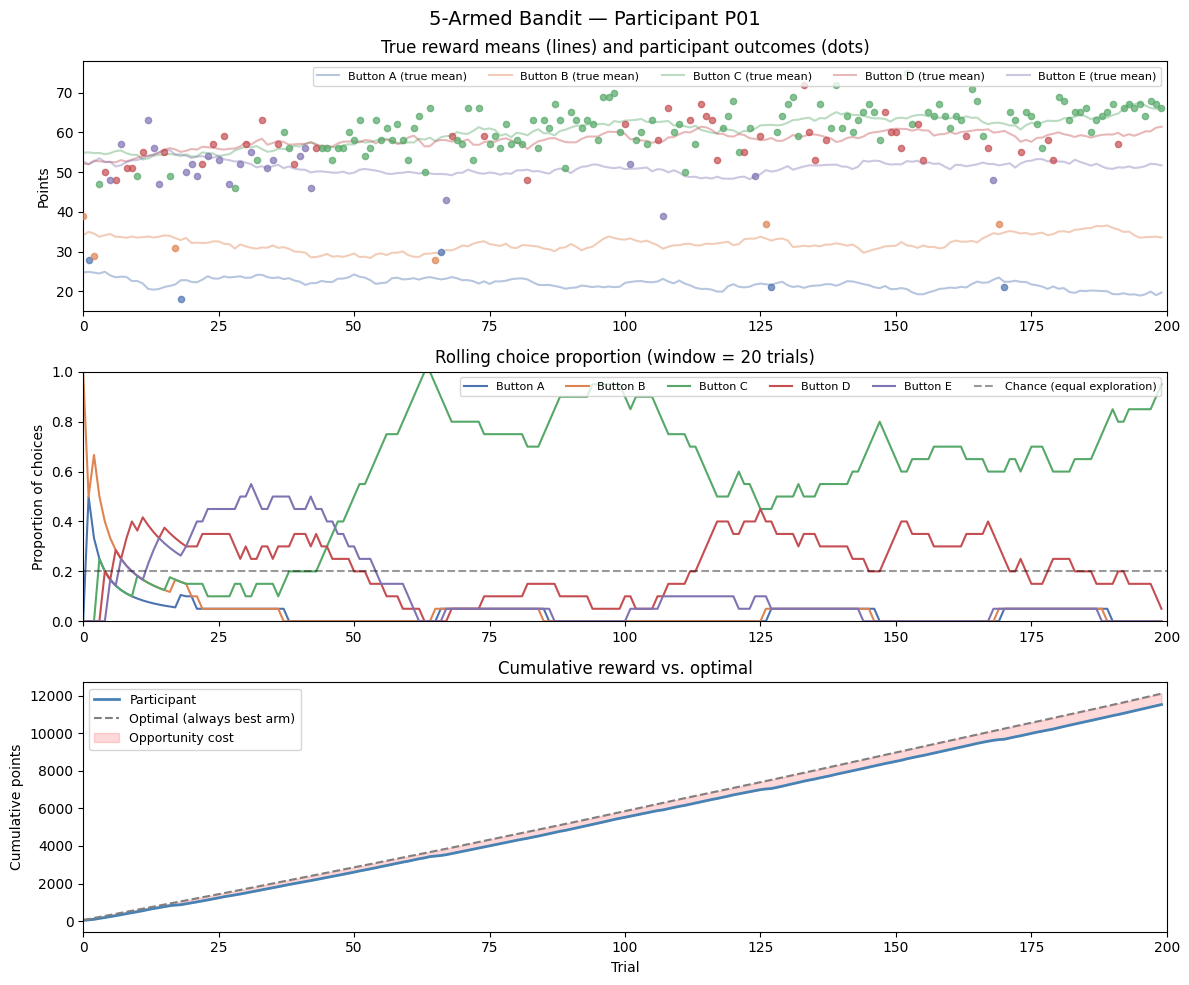

Figure saved to bandit_results_P01.png


In [9]:
if not task_state['done']:
    print('Complete the task first (Cell 3).')
else:
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    fig.suptitle(f'5-Armed Bandit — Participant {PARTICIPANT_ID}', fontsize=14)

    # ── Plot 1: True reward means + participant choices ────────────────
    ax = axes[0]
    trial_x = np.arange(N_TRIALS)
    for i in range(N_ARMS):
        ax.plot(trial_x, true_means[:, i],
                color=BUTTON_COLORS[i], alpha=0.4, linewidth=1.5,
                label=f'Button {BUTTON_LABELS[i]} (true mean)')
    # Mark participant choices
    for i in range(N_ARMS):
        mask = choices == i
        ax.scatter(np.where(mask)[0], rewards[mask],
                   color=BUTTON_COLORS[i], s=20, zorder=5, alpha=0.7)
    ax.set_ylabel('Points')
    ax.set_title('True reward means (lines) and participant outcomes (dots)')
    ax.legend(loc='upper right', fontsize=8, ncol=N_ARMS)
    ax.set_xlim(0, N_TRIALS)

    # ── Plot 2: Choice proportions per button (rolling window) ────────
    ax = axes[1]
    window = 20
    for i in range(N_ARMS):
        prop = pd.Series((choices == i).astype(float)).rolling(window, min_periods=1).mean()
        ax.plot(prop.values, color=BUTTON_COLORS[i],
                label=f'Button {BUTTON_LABELS[i]}')
    ax.axhline(1/N_ARMS, color='black', linestyle='--', alpha=0.4,
               label='Chance (equal exploration)')
    ax.set_ylabel('Proportion of choices')
    ax.set_title(f'Rolling choice proportion (window = {window} trials)')
    ax.legend(loc='upper right', fontsize=8, ncol=N_ARMS+1)
    ax.set_xlim(0, N_TRIALS)
    ax.set_ylim(0, 1)

    # ── Plot 3: Cumulative reward vs. optimal ─────────────────────────
    ax = axes[2]
    optimal_reward = true_means.max(axis=1).cumsum()
    ax.plot(np.cumsum(rewards), color='steelblue', linewidth=2,
            label='Participant')
    ax.plot(optimal_reward, color='gray', linestyle='--', linewidth=1.5,
            label='Optimal (always best arm)')
    ax.fill_between(trial_x, np.cumsum(rewards), optimal_reward,
                    alpha=0.15, color='red', label='Opportunity cost')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Cumulative points')
    ax.set_title('Cumulative reward vs. optimal')
    ax.legend(fontsize=9)
    ax.set_xlim(0, N_TRIALS)

    plt.tight_layout()
    plt.savefig(f'bandit_results_{PARTICIPANT_ID}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved to bandit_results_{PARTICIPANT_ID}.png')